# Project: Heart Disease Prediction with a Feedforward Neural Network

**Objective:** To build and evaluate a Multilayer Perceptron (MLP) for binary classification of heart disease. This notebook covers the full data loading, cleaning, preprocessing, and exploratory analysis pipeline using the complete multi-source heart disease dataset.

## 1. Import essential libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure settings for plotting
%matplotlib inline
sns.set_style('whitegrid')

## 2. Full Data Loading, Cleaning, and Processing Pipeline

In [4]:
# --- 2. Full Data Loading, Cleaning, and Processing Pipeline (Final Version) ---

# Load the full raw dataset
file_path = '../data/heart_disease_uci.csv'
df_full = pd.read_csv(file_path)
print(f"Initial number of rows loaded: {len(df_full)}")

# --- Initial Cleaning and Target Creation ---
df_full.drop(['id', 'dataset'], axis=1, inplace=True)
df_full['target'] = df_full['num'].apply(lambda x: 1 if x > 0 else 0)
df_full.drop('num', axis=1, inplace=True)
df_full.replace('?', np.nan, inplace=True)

# --- (NEW) Handle Impossible Zero/Negative Values ---
# We identified that 'trestbps' and 'chol' have impossible 0 values.
# 'oldpeak' has improbable negative values.
# We will replace these with np.nan to be imputed correctly.
df_full['trestbps'] = df_full['trestbps'].replace(0, np.nan)
df_full['chol'] = df_full['chol'].replace(0, np.nan)
df_full['oldpeak'] = df_full['oldpeak'].apply(lambda x: np.nan if x < 0 else x)

print("Impossible 0s and negatives converted to NaN for imputation.")

# --- Robust Missing Value Handling ---
max_missing_values = 4
rows_before_dropping = len(df_full)
df_full.dropna(thresh=len(df_full.columns) - max_missing_values, inplace=True)
rows_after_dropping = len(df_full)
print(f"Dropped {rows_before_dropping - rows_after_dropping} rows due to excessive missing values.")

# --- Impute Remaining Missing Values ---
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
for col in numeric_cols:
    df_full[col] = pd.to_numeric(df_full[col], errors='coerce')

# (Corrected) Impute numeric columns with the median using direct assignment
for col in numeric_cols:
    if df_full[col].isnull().any():
        median_val = df_full[col].median()
        df_full[col] = df_full[col].fillna(median_val) # Replaced inplace=True

# (Corrected) Impute categorical columns with the mode using direct assignment
categorical_cols_to_impute = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols_to_impute:
    if df_full[col].isnull().any():
        mode_val = df_full[col].mode()[0]
        df_full[col] = df_full[col].fillna(mode_val) # Replaced inplace=True

print(f"Final number of rows after cleaning: {len(df_full)}")
print(f"Final check for any remaining missing values: {df_full.isnull().sum().sum()}")

# --- Create final dataframes ---
df_cl_full = df_full.copy()
df_processed_full = df_full.copy()

# --- Feature Encoding for the ML model's dataframe ---
df_processed_full['sex'] = df_processed_full['sex'].map({'Male': 1, 'Female': 0})
df_processed_full['fbs'] = df_processed_full['fbs'].astype(bool).astype(int)
df_processed_full['exang'] = df_processed_full['exang'].astype(bool).astype(int)

ohe_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
df_processed_full = pd.get_dummies(df_processed_full, columns=ohe_cols, drop_first=True)

print("\n--- Final Processed DataFrame for Machine Learning ---")
print(f"Shape of the final processed data: {df_processed_full.shape}")
df_processed_full.head()

Initial number of rows loaded: 920
Impossible 0s and negatives converted to NaN for imputation.
Dropped 67 rows due to excessive missing values.
Final number of rows after cleaning: 853
Final check for any remaining missing values: 0

--- Final Processed DataFrame for Machine Learning ---
Shape of the final processed data: (853, 21)


C:\Users\usuario\AppData\Local\Temp\ipykernel_22004\361986479.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_full[col] = df_full[col].fillna(mode_val) # Replaced inplace=True


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,target,cp_atypical angina,...,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0,False,...,True,False,False,False,False,False,False,False,False,False
1,67,1,160.0,286.0,0,108.0,1,1.5,1,False,...,False,False,False,True,False,False,False,True,True,False
2,67,1,120.0,229.0,0,129.0,1,2.6,1,False,...,False,False,False,True,False,False,True,False,False,True
3,37,1,130.0,250.0,0,187.0,0,3.5,0,False,...,False,True,False,False,False,False,False,False,True,False
4,41,0,130.0,204.0,0,172.0,0,1.4,0,True,...,False,False,False,False,True,False,False,False,True,False


## 3. Descriptive Statistics

Now that the data is cleaned and imputed, we can look at the descriptive statistics for the numerical features to understand their central tendency and spread.

In [5]:
# Display descriptive statistics for the numerical columns
# We use .T to transpose the matrix, making it easier to read
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
print(df_cl_full[numerical_features].describe().T)

          count        mean        std   min    25%    50%    75%    max
age       853.0   53.220399   9.355810  28.0   47.0   54.0   60.0   77.0
trestbps  853.0  132.498242  18.394773  80.0  120.0  130.0  140.0  200.0
chol      853.0  245.577960  52.275252  85.0  217.0  240.0  267.0  603.0
thalch    853.0  137.731536  25.757207  60.0  120.0  140.0  157.0  202.0
oldpeak   853.0    0.901524   1.066656   0.0    0.0    0.5    1.5    6.2


## 4. Exploratory Data Analysis (EDA)

This analysis is performed on the `df_cl_full` dataframe, which has been cleaned and imputed but retains its original categorical labels for better interpretability in plots.

### 4.1. Target Variable Analysis

C:\Users\usuario\AppData\Local\Temp\ipykernel_22004\448471505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_cl_full, palette='viridis')


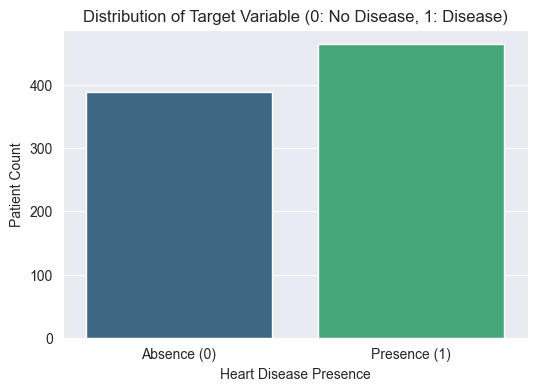

Percentage of Presence (1): 54.40%
Percentage of Absence (0): 45.60%


In [6]:
# Plot the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_cl_full, palette='viridis')
plt.title('Distribution of Target Variable (0: No Disease, 1: Disease)')
plt.xlabel('Heart Disease Presence')
plt.ylabel('Patient Count')
plt.xticks([0, 1], ['Absence (0)', 'Presence (1)'])
plt.show()

# Print exact percentages
target_perc = df_cl_full['target'].value_counts(normalize=True) * 100
print(f"Percentage of Presence (1): {target_perc.get(1, 0):.2f}%")
print(f"Percentage of Absence (0): {target_perc.get(0, 0):.2f}%")

### 4.2. Feature Analysis vs. Target

--- Categorical Features vs. Target ---


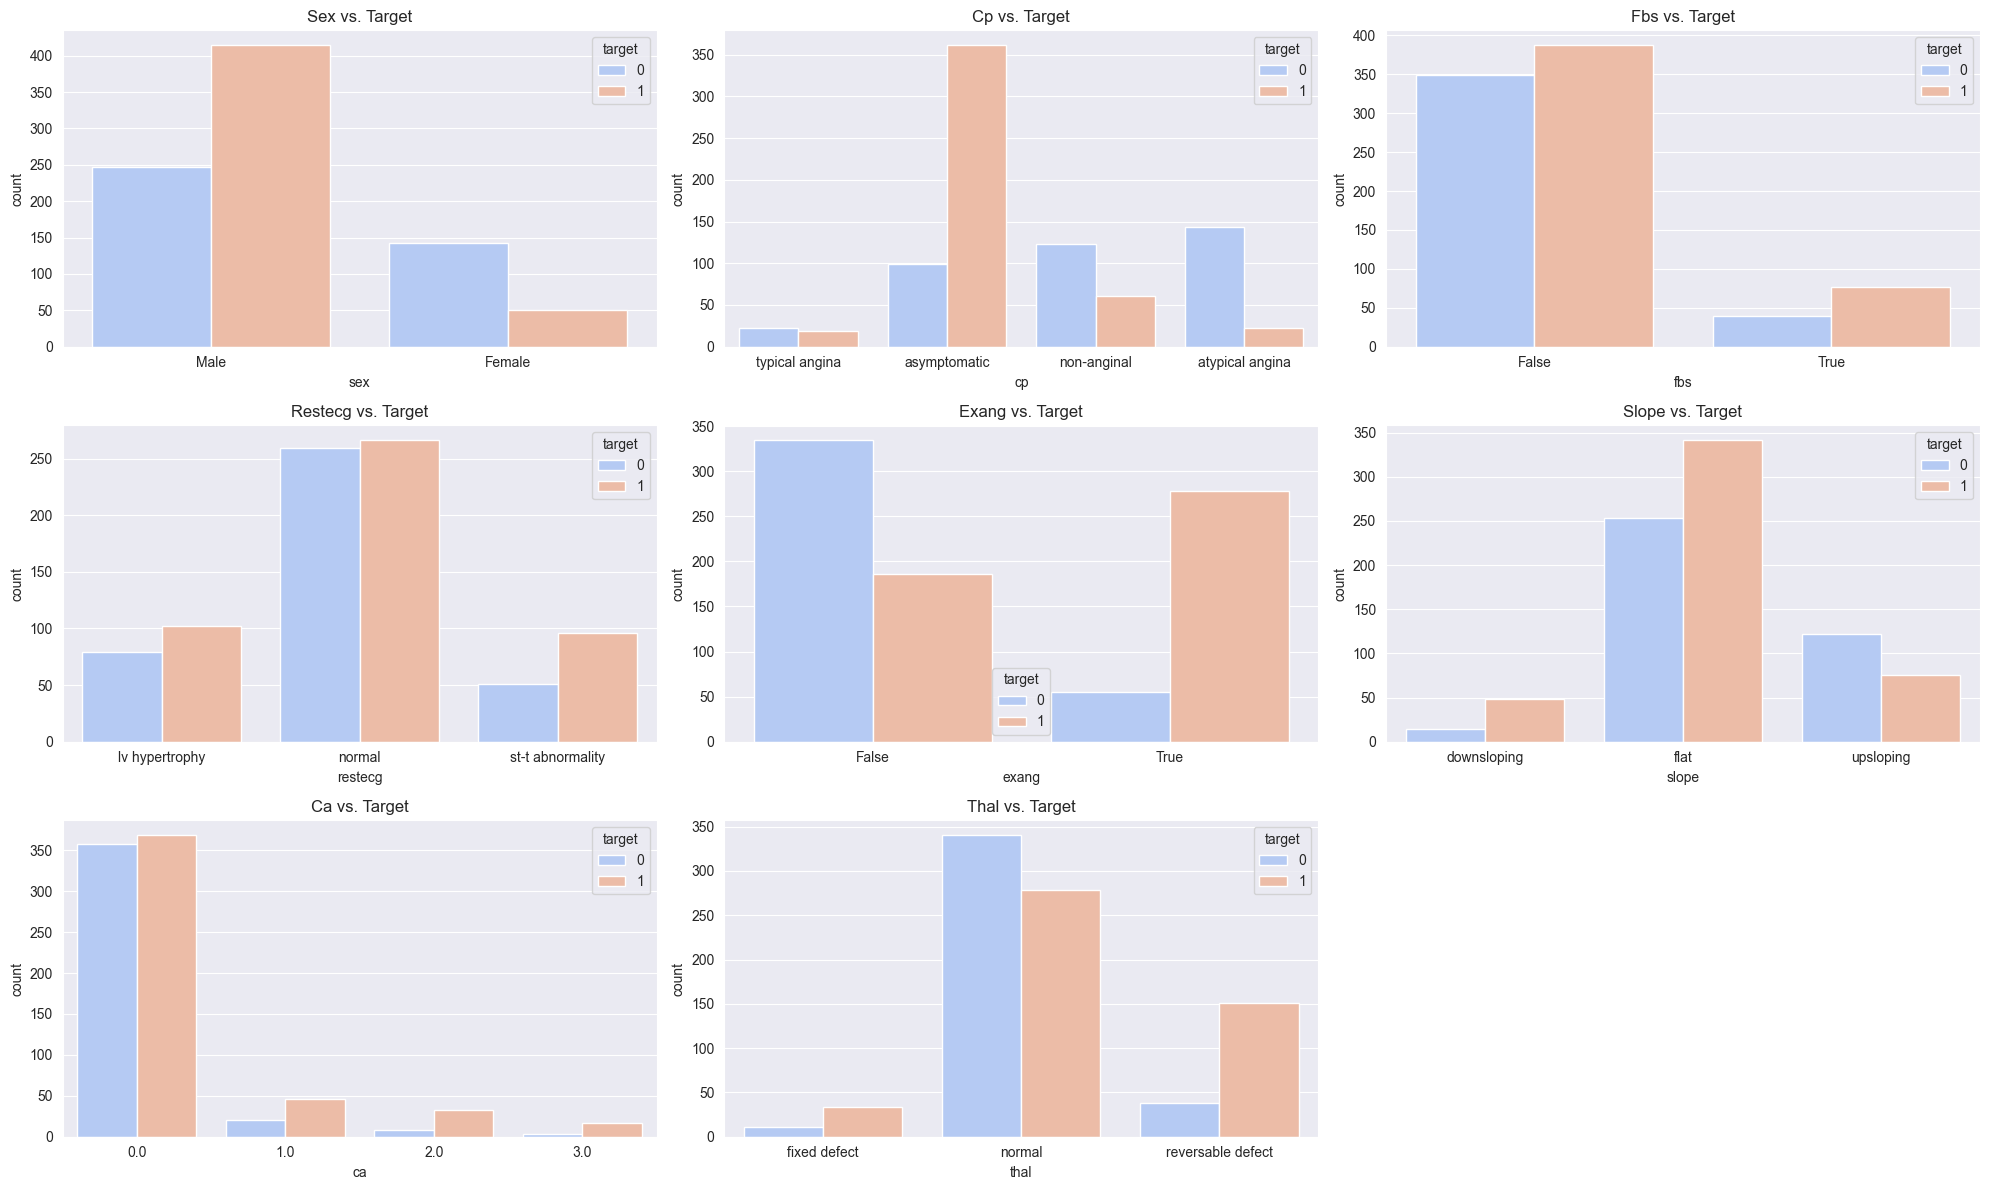


--- Numerical Features Distribution by Target ---


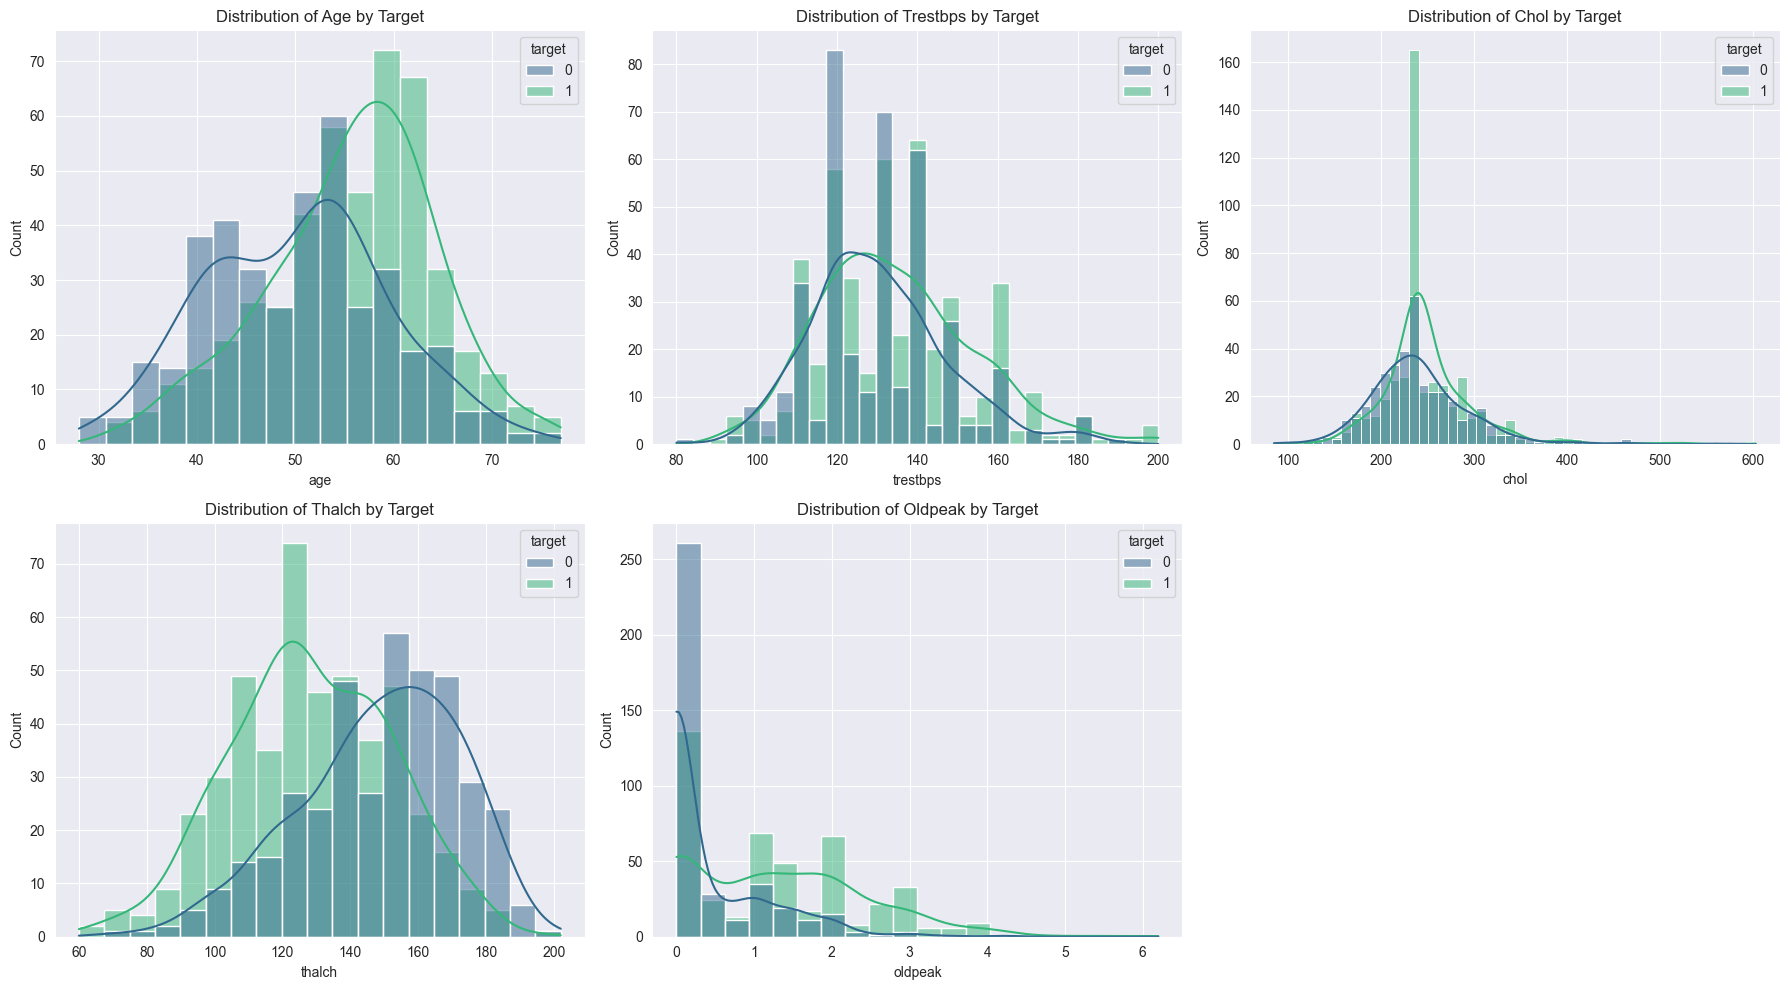

In [7]:
# Define feature lists for plotting
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Plot categorical features against the target
print("--- Categorical Features vs. Target ---")
plt.figure(figsize=(20, 12))
for i, feature in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=feature, data=df_cl_full, hue='target', palette='coolwarm')
    plt.title(f'{feature.capitalize()} vs. Target')
    plt.tight_layout()
plt.show()

# Plot distributions of numerical features separated by target
print("\n--- Numerical Features Distribution by Target ---")
plt.figure(figsize=(18, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data=df_cl_full, x=feature, hue='target', kde=True, palette='viridis')
    plt.title(f'Distribution of {feature.capitalize()} by Target')
    plt.tight_layout()
plt.show()

### 4.3. Correlation Matrix

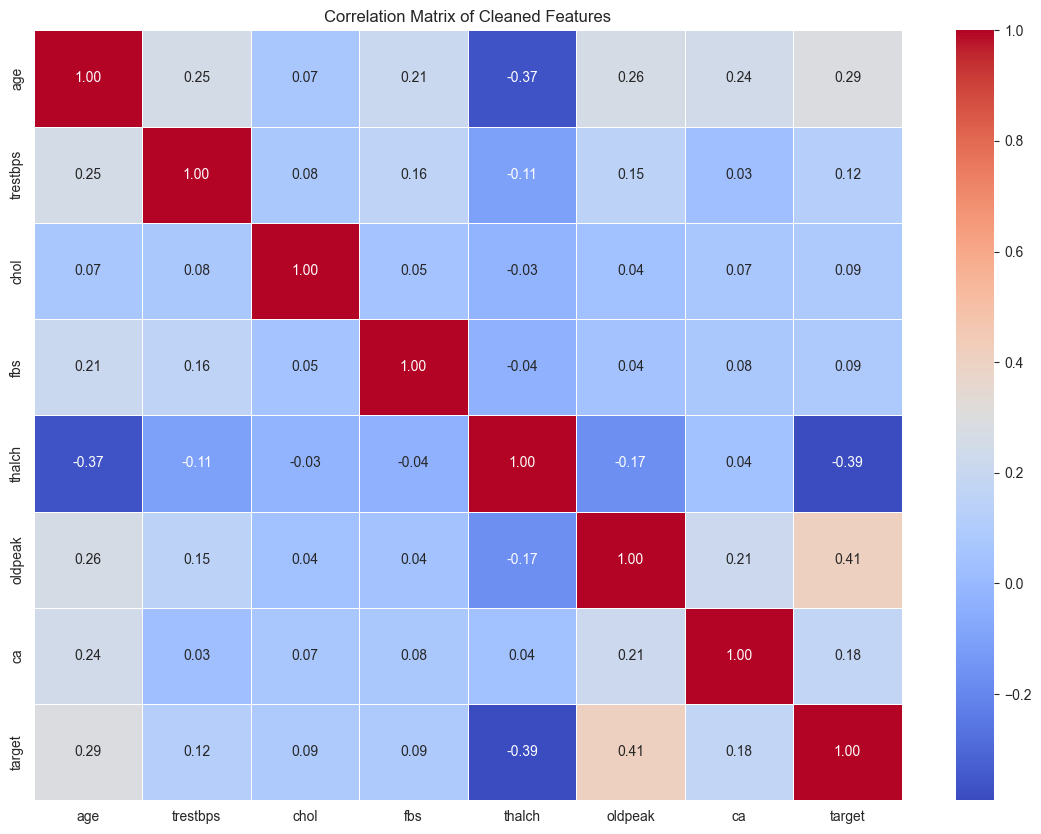

In [8]:
# Calculate the correlation matrix on the cleaned (but not one-hot encoded) dataframe
corr_matrix = df_cl_full.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Cleaned Features')
plt.show()

### 4.4. Conclusions from Correlation Analysis

The correlation matrix provides valuable insights into the linear relationships between variables and their potential predictive power for our `target` (presence of heart disease).

**Key Findings:**

* **Strongest Predictors:**
    * Several features show a significant linear relationship with the target. The strongest **positive correlations** are observed with `oldpeak` and `exang`, indicating that higher ST depression and the presence of exercise-induced angina are strong indicators of heart disease.
    * Conversely, `thalach` (maximum heart rate achieved) exhibits a strong **negative correlation**, suggesting that a higher maximum heart rate is a strong indicator of the *absence* of heart disease. Features related to chest pain type (`cp`) and the slope of the ST segment (`slope`) also show notable negative correlations.

* **Variables with Low Linear Correlation:**
    * Features such as `chol` (cholesterol), `trestbps` (resting blood pressure), and `fbs` (fasting blood sugar) show very weak linear correlations with the target (values close to 0).
    * **Note:** While they are not strong *linear* predictors on their own, they might still hold predictive power through more complex, non-linear interactions that our neural network may be able to capture.

* **Inter-Feature Correlation (Multicollinearity):**
    * There is a moderate negative correlation between `age` and `thalach`, which is clinically expected. No strong multicollinearity (correlation > 0.7 or < -0.7) is observed between the main predictor variables, suggesting that each feature provides relatively independent information.

This analysis helps us understand which features are likely to be most influential in our model and provides a baseline understanding of the data's structure before we begin training the MLP.

## 5. Data Splitting and Scaling (Prerequisite for Feature Importance)

To accurately determine feature importance, we must first split our data. We will train a model on the *training set* to get the importance scores. This prevents any information from the *test set* from "leaking" into our analysis.

In [10]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Separate features (X) and target (y) ---
# We use the fully processed dataframe for this
X = df_processed_full.drop('target', axis=1)
y = df_processed_full['target']

# --- 2. Split data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (682, 20)
X_test shape: (171, 20)


In [11]:
# --- 3. Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store feature names for later plotting
# We get the column names from X *before* scaling (as scaling turns it into a NumPy array)
feature_names = X.columns

## 6. Feature Importance Analysis

Now that we have a scaled training set, we will use a Random Forest Classifier as a proxy model to evaluate the relative importance of each feature. A Random Forest is an "ensemble" model that is very good at this task. We will fit it on the training data and then plot the importance scores.

C:\Users\usuario\AppData\Local\Temp\ipykernel_22004\322866981.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


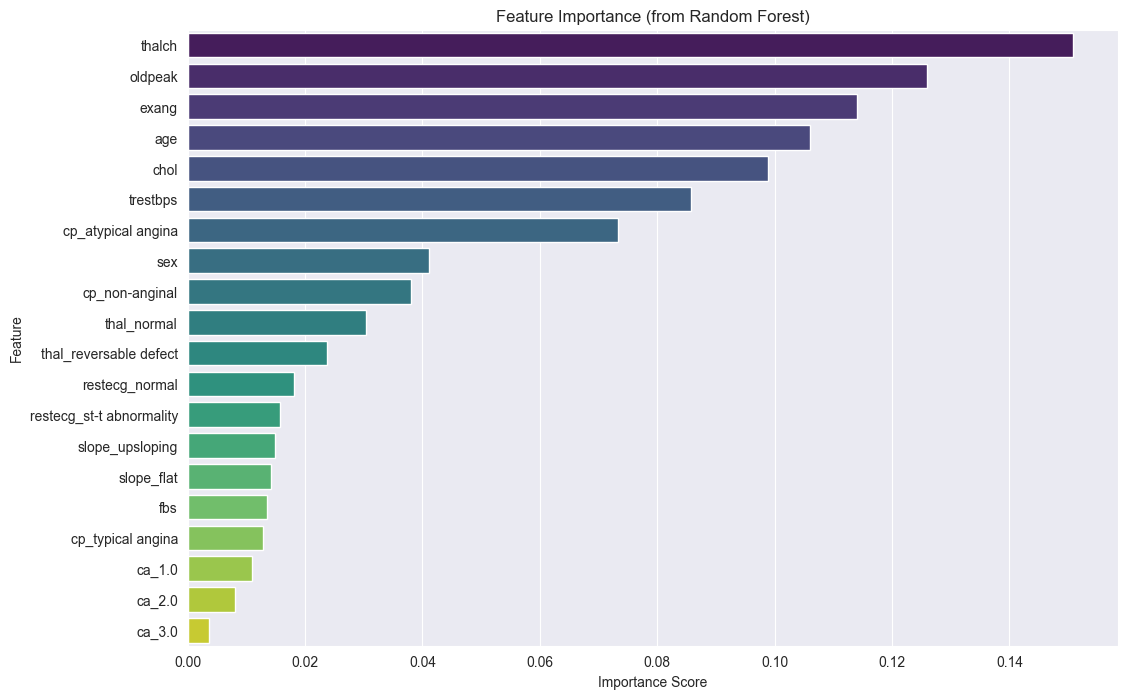

Top 10 Most Important Features:
               Feature  Importance
5               thalch    0.150881
7              oldpeak    0.126016
6                exang    0.113974
0                  age    0.106072
3                 chol    0.098808
2             trestbps    0.085775
8   cp_atypical angina    0.073262
1                  sex    0.041136
9       cp_non-anginal    0.038030
18         thal_normal    0.030414


In [12]:
from sklearn.ensemble import RandomForestClassifier

# --- 1. Train the Random Forest model ---
# We create an instance of the classifier and fit it
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# --- 2. Get feature importances ---
importances = rf_model.feature_importances_

# --- 3. Create a DataFrame for visualization ---
# We sort the features by their importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- 4. Plot the results ---
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance (from Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Print the top 10 features
print("Top 10 Most Important Features:")
print(importance_df.head(10))

### (Optional) 7. Export the Cleaned DataFrames to CSV Files

In [13]:
# Define file paths for the output files
cleaned_eda_path = '../data/cleaned_heart_disease_for_eda.csv'
processed_ml_path = '../data/processed_heart_disease_for_ml.csv'

# Export the dataframe used for visualization (human-readable)
# The index=False argument prevents pandas from writing row indices as a column
df_cl_full.to_csv(cleaned_eda_path, index=False)
print(f"Cleaned data for EDA successfully saved to: {cleaned_eda_path}")

# Export the dataframe ready for machine learning (fully numeric)
df_processed_full.to_csv(processed_ml_path, index=False)
print(f"Processed data for ML successfully saved to: {processed_ml_path}")

Cleaned data for EDA successfully saved to: ./data/cleaned_heart_disease_for_eda.csv
Processed data for ML successfully saved to: ./data/processed_heart_disease_for_ml.csv


## 8. Data Splitting and Scaling

Before we build the model, we need to prepare the data for training and evaluation. This involves:
1.  Separating the features (X) from the target variable (y).
2.  Splitting the data into training and testing sets.
3.  Scaling the features to ensure stable and efficient training.

### 8.1. Concept: Why Split the Data?

Before training, we must divide our dataset. If we train the model on all the data we have, it might become an "expert" on that specific data but fail completely when it sees a new, unseen patient. This is called **overfitting**. It's like a student who memorizes the answers to a practice exam but doesn't understand the concepts, so they fail the real exam.

To solve this, we split our data into two sets:

* **Training Set**: Typically 80% of the data. The model will learn from this set, identifying patterns that correlate patient features with the presence of heart disease.
* **Test Set**: The remaining 20%. This set is kept completely separate during training. We use it at the very end as a "final exam" to get an unbiased evaluation of how well the model can generalize its knowledge to new data.

In [15]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Separate features (X) and target (y) ---
# Our target is the 'target' column. X is everything else.
X = df_processed_full.drop('target', axis=1)
y = df_processed_full['target']

# --- 2. Split data into training and testing sets ---
# We'll use an 80/20 split.
# random_state=42 ensures that the split is the same every time we run the code,
# which is crucial for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# The 'stratify=y' argument ensures that the proportion of classes in the target
# is the same in both the training and testing sets. It's good practice for classification.

# Print the shapes of the resulting datasets to verify
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (682, 20)
Shape of X_test: (171, 20)
Shape of y_train: (682,)
Shape of y_test: (171,)


### 8.2. Concept: Why Scale the Features?

Neural networks are sensitive to the scale of the input data. In our dataset, a feature like `age` ranges from ~30 to ~70, while `oldpeak` ranges from 0 to ~6. Without scaling, the optimization algorithm (Gradient Descent) would give more weight to `age` simply because its values are numerically larger. This can make the training process unstable and much slower to converge.

To address this, we scale our features so they are all on a similar range. The most common and robust technique is **Standardization**.

* **Standardization**: This method transforms each feature to have a **mean of 0** and a **standard deviation of 1**. This ensures that all features contribute equally to the learning process, leading to a more stable and efficient training.

In [ ]:
# --- 3. Scale the features ---
# We use StandardScaler to scale the data to have a mean of 0 and a standard deviation of 1.

# IMPORTANT: We fit the scaler ONLY on the training data to avoid data leakage
# from the test set. Then, we transform both the training and test sets.
scaler = StandardScaler()

# Fit the scaler on the training features and transform them
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test features using the SAME scaler
X_test_scaled = scaler.transform(X_test)

# The output is a NumPy array. Let's see the first 5 rows of the scaled training data.
print("First 5 rows of scaled training data (X_train_scaled):")
print(X_train_scaled[:5])

## 9. Global Data Analysis: Final Summary & Conclusions

<!-- This completes the comprehensive data analysis phase. We have successfully prepared and understood the dataset, fulfilling all analytical requirements before modeling. -->

### Key Methodological Achievements:

1.  **Robust Cleaning:** We loaded the full 920-row multi-source dataset and performed critical data sanitation. We identified and corrected not only standard `?` nulls but also **medically impossible values** (`0` for `cholesterol` and `trestbps`, negative `oldpeak`), replacing them with `NaN`.
2.  **High-Quality Imputation:** After dropping a small number of non-recoverable rows, we were left with **853 high-quality samples**. We successfully imputed the remaining missing values using the median (for numerical) and mode (for categorical), resulting in a complete dataset with zero missing values.
3.  **Data Quality Confirmed:** The descriptive statistics (`.describe()`) confirm our data is now plausible, with realistic minimum values and means for all features (e.g., `chol` mean ~245).
4.  **Ideal Target Balance:** The target variable is almost perfectly balanced (**54.40% Presence** vs. **45.60% Absence**), eliminating the need for complex re-sampling techniques and providing an ideal foundation for training.
5.  **Methodologically Sound Preprocessing:** We correctly split the data using `stratify=y` (preserving the class balance) and prevented data leakage by fitting the `StandardScaler` **only** on the training data.

### Key Analytical Insights:

* **Insight 1: Linear vs. Non-Linear Importance.** Our analysis revealed a crucial insight by comparing two methods:
    * **Correlation (Linear):** The heatmap showed that `chol` and `trestbps` have a very weak *linear* relationship with the target.
    * **Feature Importance (Non-Linear):** The Random Forest proxy model ranked `chol` and `trestbps` as the **5th and 6th most important features**, respectively.
    * **Conclusion:** This strongly suggests that these variables are indeed predictive, but their relationship with heart disease is **non-linear**. This is the core justification for using an advanced model like an MLP, which is designed to find precisely these complex patterns.

* **Insight 2: Stress-Test Features are Dominant.** Both analyses confirmed that the results from the patient's stress test (`thalch` - max heart rate, `oldpeak` - ST depression, `exang` - exercise angina) are the most powerful and consistent predictors in the dataset.

* **Insight 3: Categorical Features are Key.** While the proxy model focused on numerical features, our correlation analysis and the feature importance plot (e.g., `cp_atypical angina`, `thal_normal`) confirm that categorical features relating to chest pain type and thallium scan results are also highly predictive.

**Final Verdict:**
The data is now thoroughly understood, cleaned, scaled, and split. We have a robust training set (`X_train_scaled`, `y_train`) and a "held-out" test set (`X_test_scaled`, `y_test`) for final evaluation. The feature analysis confirms that our dataset contains strong, complex, and non-linear predictive signals.

**We are fully prepared to proceed with the primary task: implementing and training our Multilayer Perceptron (MLP) from scratch.**